In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv("movies.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   movie_id           3000 non-null   int64  
 1   title              3000 non-null   str    
 2   release_year       3000 non-null   int64  
 3   genre              3000 non-null   str    
 4   budget             3000 non-null   float64
 5   revenue            3000 non-null   float64
 6   runtime            3000 non-null   int64  
 7   imdb_rating        3000 non-null   float64
 8   metascore          2578 non-null   float64
 9   votes              3000 non-null   float64
 10  director           3000 non-null   str    
 11  main_actor         3000 non-null   str    
 12  oscar_nominations  3000 non-null   int64  
 13  oscar_wins         3000 non-null   int64  
dtypes: float64(5), int64(5), str(4)
memory usage: 328.3 KB
None


PART 1: DATA EXPLORATION & CLEANING

In [3]:
# 1.1 Initial exploration
print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Data types:\n", df.dtypes)

Shape: (3000, 14)
Missing values:
 movie_id               0
title                  0
release_year           0
genre                  0
budget                 0
revenue                0
runtime                0
imdb_rating            0
metascore            422
votes                  0
director               0
main_actor             0
oscar_nominations      0
oscar_wins             0
dtype: int64
Data types:
 movie_id               int64
title                    str
release_year           int64
genre                    str
budget               float64
revenue              float64
runtime                int64
imdb_rating          float64
metascore            float64
votes                float64
director                 str
main_actor               str
oscar_nominations      int64
oscar_wins             int64
dtype: object


In [4]:
# 1.2 Handle missing metascore 
df['metascore'] = df.groupby('genre')['metascore'].transform(lambda x: x.fillna(x.median()))

In [5]:
# 1.3
df = df[df['budget'] >= 0]      
df = df[df['revenue'] >= 0]      
df = df[df['runtime'] >= 10]    

def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    return outliers

outliers_budget = find_outliers('budget')
outliers_revenue = find_outliers('revenue')
outliers_runtime = find_outliers('runtime')
outliers_votes = find_outliers('votes')

print("Number of budget outliers:", len(outliers_budget))
print("Number of revenue outliers:", len(outliers_revenue))
print("Number of runtime outliers:", len(outliers_runtime))
print("Number of votes outliers:", len(outliers_votes))

inconsistent_movies = df[df['revenue'] < df['budget']]
print("Number of inconsistent movies (revenue < budget):", len(inconsistent_movies))

Number of budget outliers: 209
Number of revenue outliers: 245
Number of runtime outliers: 11
Number of votes outliers: 255
Number of inconsistent movies (revenue < budget): 129


PART 2: DESCRIPTIVE STATISTICS 

In [6]:
numerical_cols = ['budget','revenue','runtime','imdb_rating','metascore','votes','oscar_nominations','oscar_wins']

# 2.1 Numerical summary
summary = df[numerical_cols].agg(['mean','median','var','std','min','max','count'])
summary.loc['range'] = summary.loc['max'] - summary.loc['min']
summary.loc['IQR'] = df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
print("\nNumerical summary:\n", summary)


Numerical summary:
              budget       revenue      runtime  imdb_rating    metascore  \
mean      36.257010    153.206637   120.307333     6.591033    65.489000   
median    23.710000     79.535000   121.000000     6.600000    66.000000   
var     1433.343845  60851.923385   622.239626     1.017796   206.157431   
std       37.859528    246.681826    24.944731     1.008859    14.358183   
min        1.300000      1.580000    60.000000     3.200000    13.000000   
max      350.000000   2800.000000   201.000000     9.500000   100.000000   
count   3000.000000   3000.000000  3000.000000  3000.000000  3000.000000   
range    348.700000   2798.420000   141.000000     6.300000    87.000000   
IQR       32.062500    137.610000    34.000000     1.400000    17.000000   

               votes  oscar_nominations   oscar_wins  
mean      164.880000           1.604667     0.562667  
median     91.500000           1.000000     0.000000  
var     49097.899300           2.444526     0.656292 

In [7]:
# 2.2 Categorical summary
categorical_cols = ['genre','director','main_actor']
for col in categorical_cols:
    print(f"Column: {col}")
    print("Unique values:", df[col].nunique())
    print("Top 10 most frequent:")
    print(df[col].value_counts().head(10))
    print("Proportions (%):")
    print(df[col].value_counts(normalize=True).head(10)*100)


Column: genre
Unique values: 8
Top 10 most frequent:
genre
Sci-Fi       397
Action       387
Romance      381
Horror       376
Comedy       375
Animation    370
Drama        366
Thriller     348
Name: count, dtype: int64
Proportions (%):
genre
Sci-Fi       13.233333
Action       12.900000
Romance      12.700000
Horror       12.533333
Comedy       12.500000
Animation    12.333333
Drama        12.200000
Thriller     11.600000
Name: proportion, dtype: float64
Column: director
Unique values: 10
Top 10 most frequent:
director
Patty Jenkins        320
Steven Spielberg     308
Denis Villeneuve     306
Martin Scorsese      303
Quentin Tarantino    303
James Cameron        297
Christopher Nolan    295
Greta Gerwig         292
Ridley Scott         292
Alfonso Cuarón       284
Name: count, dtype: int64
Proportions (%):
director
Patty Jenkins        10.666667
Steven Spielberg     10.266667
Denis Villeneuve     10.200000
Martin Scorsese      10.100000
Quentin Tarantino    10.100000
James Cameron   

In [8]:
#2.3
cv = df[numerical_cols].std() / df[numerical_cols].mean()
print("Coefficient of Variation :\n", cv)

skewness = 3 * (df[numerical_cols].mean() - df[numerical_cols].median()) / df[numerical_cols].std()
print("\nSkewness:\n", skewness)

Coefficient of Variation :
 budget               1.044199
revenue              1.610125
runtime              0.207342
imdb_rating          0.153065
metascore            0.219246
votes                1.343889
oscar_nominations    0.974344
oscar_wins           1.439784
dtype: float64

Skewness:
 budget               0.994229
revenue              0.895951
runtime             -0.083304
imdb_rating         -0.026664
metascore           -0.106768
votes                0.993499
oscar_nominations    1.160219
oscar_wins           2.083646
dtype: float64


2.3 (3)

1.Budgets and revenues vary greatly, with an average budget of about $36M and average revenue of $153M, while some movies generate extremely high revenues as outliers.
2.Genres are distributed almost evenly, with Sci-Fi at 13%, Action at 12.9%, and Thriller at 11.6%, showing no single dominant genre.
3.Some actors and directors appear frequently, for example, Ryan Gosling is in 11% of movies and Patty Jenkins directed 10%, indicating recurring “top” industry figures.


PART 3: DISTRIBUTION ANALYSIS 

IndexError: index 4 is out of bounds for axis 1 with size 4

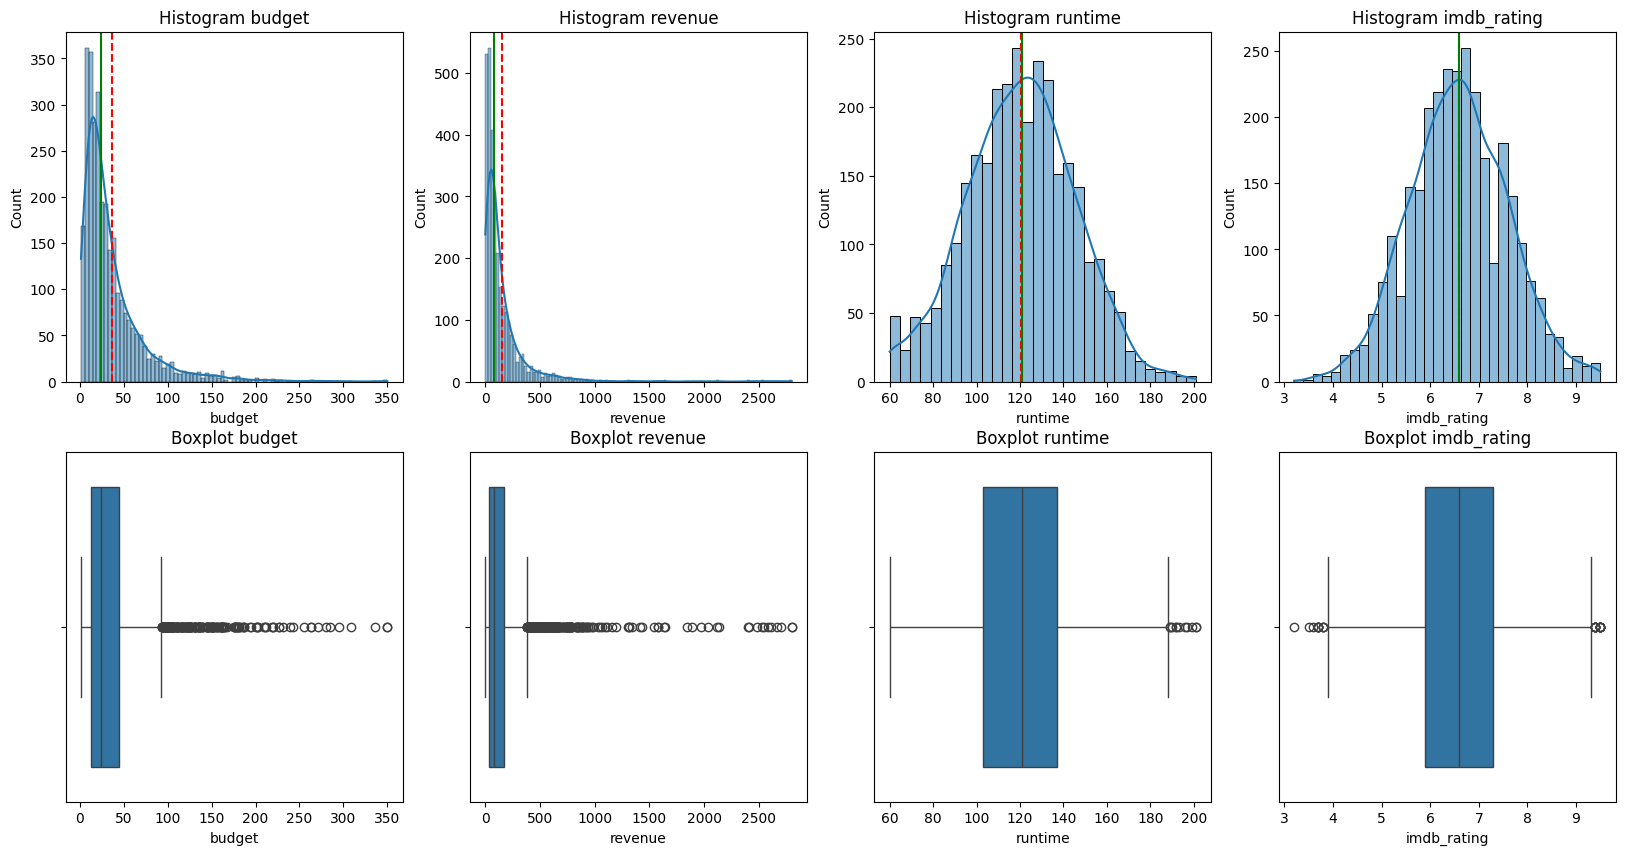

In [18]:
#3.1
fig, axes = plt.subplots(2,4, figsize=(20,10))
for i, col in enumerate(numerical_cols):
    ax_hist = axes[0,i]
    ax_box = axes[1,i]
    
    sns.histplot(df[col], kde=True, ax=ax_hist)
    ax_hist.axvline(df[col].mean(), color='red', linestyle='--')
    ax_hist.axvline(df[col].median(), color='green', linestyle='-')
    ax_hist.set_title(f'Histogram {col}')
    
    #sns.boxplot(x=df[col], ax=ax_box)
    sns.boxplot(x=pd.to_numeric(df[col], errors='coerce'), ax=ax_box)

    ax_box.set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()


In [10]:
#3.2
columns = ['budget', 'revenue', 'votes']
outliers_list = []
for col in columns:
    outliers_list.append(find_outliers(col))

outliers_df = pd.concat(outliers_list).drop_duplicates()
total_revenue = df['revenue'].sum()
outliers_revenue = outliers_df['revenue'].sum()

percentage = (outliers_revenue / total_revenue) * 100

print(f"Outlier movies contribute {percentage:.2f}% of total revenue.")

top5 = outliers_df.sort_values(by='revenue', ascending=False).head(5)
print(top5[['movie_id', 'budget', 'revenue', 'votes']])
   

Outlier movies contribute 49.87% of total revenue.
      movie_id  budget  revenue  votes
1610      1611  284.23  2800.00  137.6
2925      2926  295.28  2800.00  126.9
1975      1976  209.99  2702.20   68.0
1280      1281  242.61  2670.61   31.8
326        327  200.33  2613.96   49.8


Some movies have no many votes but can still be outliers in budget and revenue; the five selected outlier movies have high budgets, high revenue, showing their popularity and confirming that they are real blockbusters, not data errors.

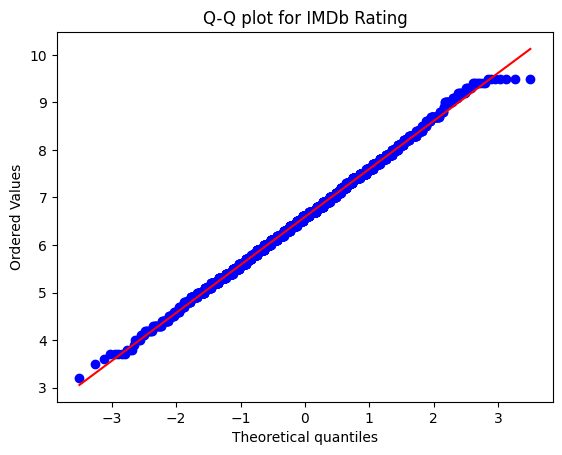

1 std: 2032 ( 67.73333333333333 % )
2 std: 2861 ( 95.36666666666666 % )
3 std: 2998 ( 99.93333333333332 % )


In [11]:
#3.3
stats.probplot(df['imdb_rating'], dist="norm", plot=plt)
plt.title('Q-Q plot for IMDb Rating')
plt.show()

ratings = df['imdb_rating'].dropna()
mean = ratings.mean()
std = ratings.std()

within_1_std = ((ratings >= mean - std) & (ratings <= mean + std)).sum()
within_2_std = ((ratings >= mean - 2*std) & (ratings <= mean + 2*std)).sum()
within_3_std = ((ratings >= mean - 3*std) & (ratings <= mean + 3*std)).sum()

total = len(ratings)

print("1 std:", within_1_std, "(", within_1_std/total*100, "% )")
print("2 std:", within_2_std, "(", within_2_std/total*100, "% )")
print("3 std:", within_3_std, "(", within_3_std/total*100, "% )")

PART 4: RELATIONSHIP ANALYSIS

                     budget   revenue   runtime  imdb_rating  metascore  \
budget             1.000000  0.737471 -0.030352     0.008384   0.025815   
revenue            0.737471  1.000000 -0.028832    -0.006421   0.012381   
runtime           -0.030352 -0.028832  1.000000    -0.012471  -0.013327   
imdb_rating        0.008384 -0.006421 -0.012471     1.000000   0.589700   
metascore          0.025815  0.012381 -0.013327     0.589700   1.000000   
votes             -0.025310 -0.023311 -0.014114    -0.018932   0.000773   
oscar_nominations -0.020614 -0.020199 -0.011914     0.592217   0.343626   
oscar_wins        -0.034692 -0.021194 -0.021859     0.391926   0.214585   

                      votes  oscar_nominations  oscar_wins  
budget            -0.025310          -0.020614   -0.034692  
revenue           -0.023311          -0.020199   -0.021194  
runtime           -0.014114          -0.011914   -0.021859  
imdb_rating       -0.018932           0.592217    0.391926  
metascore          

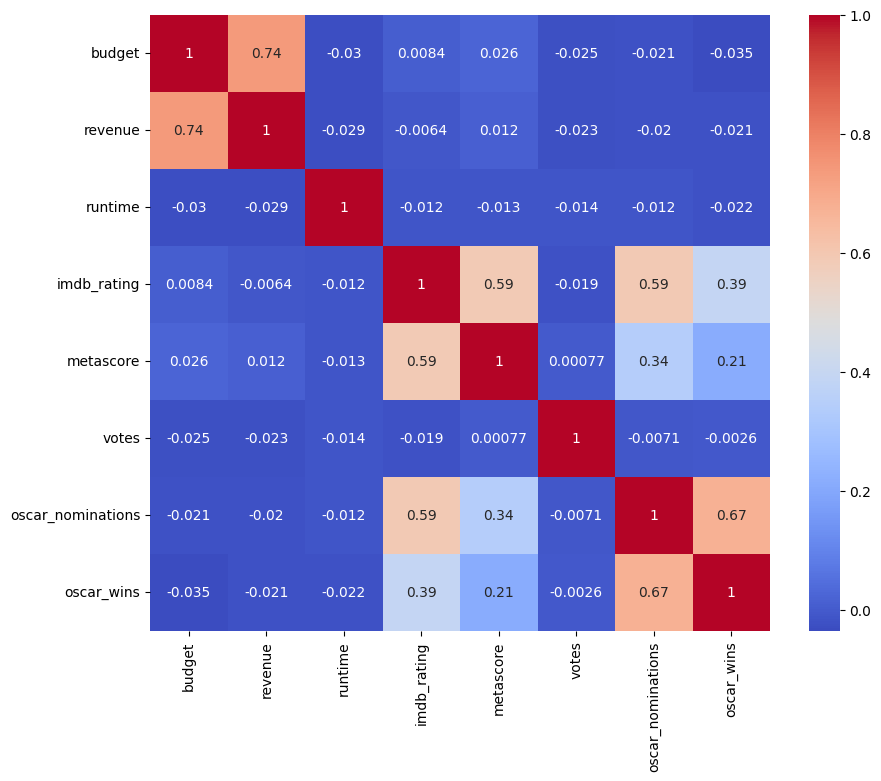

In [12]:
#4.1
numerical_cols = ['budget', 'revenue', 'runtime', 'imdb_rating', 'metascore', 'votes', 'oscar_nominations', 'oscar_wins']
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

<Figure size 1200x1000 with 0 Axes>

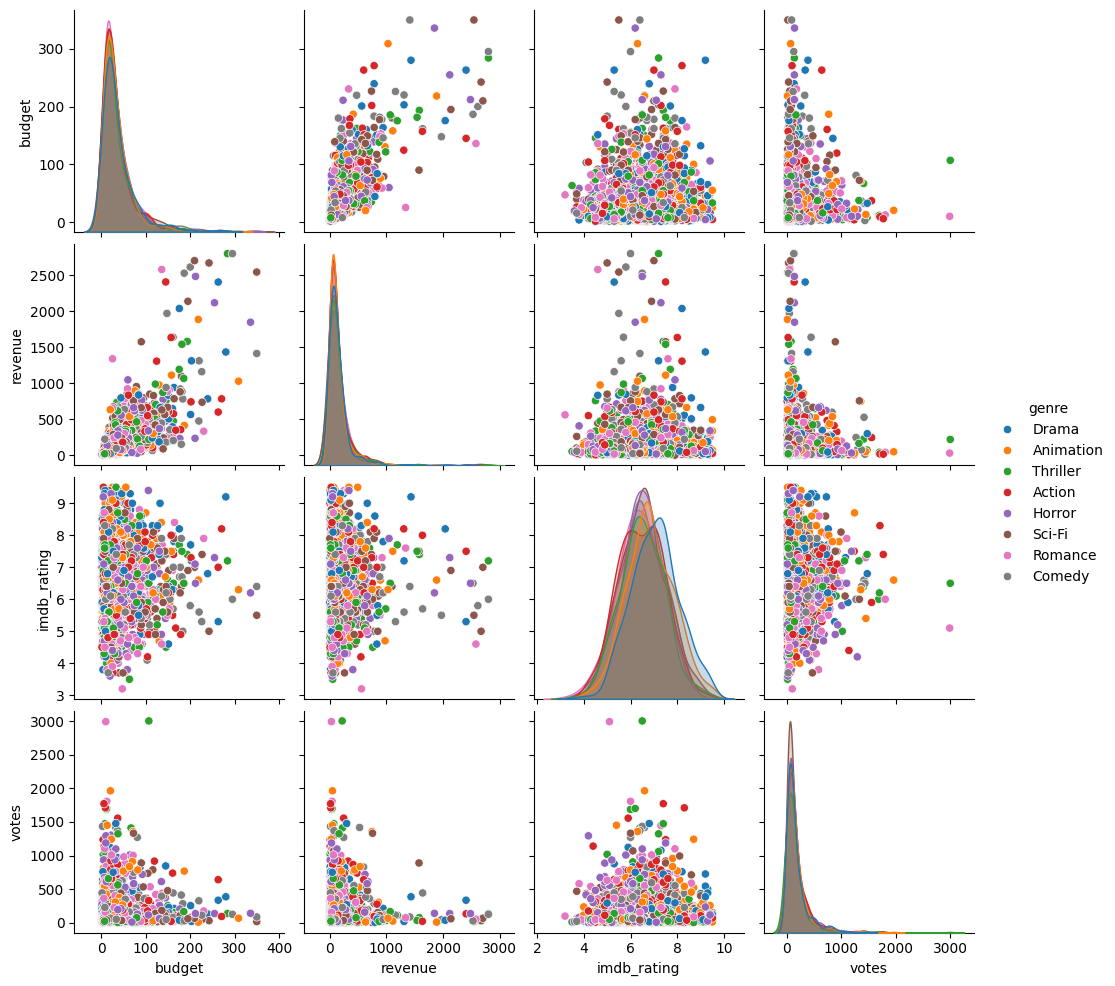

In [13]:
# 4.2 Scatter plot matrix
plt.figure(figsize=(12,10))
sns.pairplot(df, vars=['budget','revenue','imdb_rating','votes'], hue='genre', kind='scatter')
plt.show()

Correlation:                profit_margin  imdb_rating
profit_margin       1.000000     0.000083
imdb_rating         0.000083     1.000000


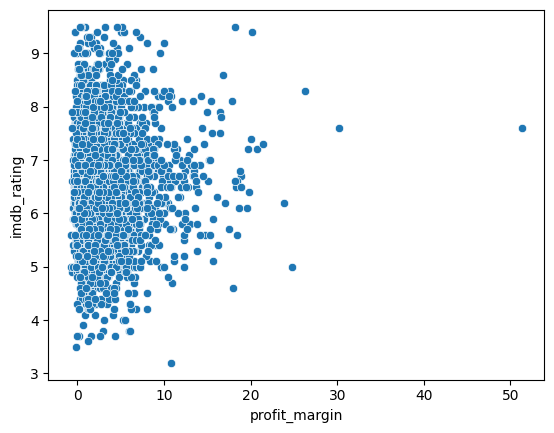

In [14]:
# 4.3 
df['profit_margin'] = np.where(df['budget']==0, np.nan, (df['revenue']-df['budget'])/df['budget'])
corr = df[['profit_margin','imdb_rating']].corr()
print("Correlation:", corr)
sns.scatterplot(x='profit_margin', y='imdb_rating', data=df)
plt.show()

PART 5: COMPARATIVE ANALYSIS 

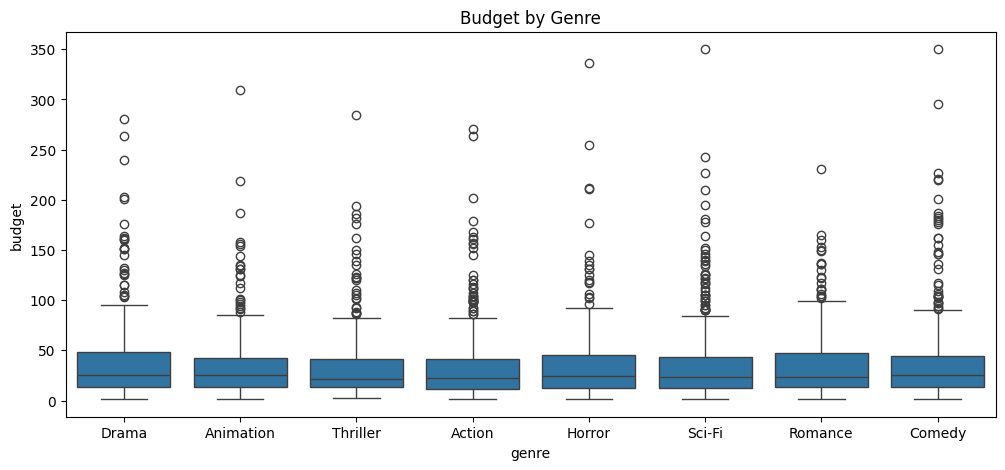

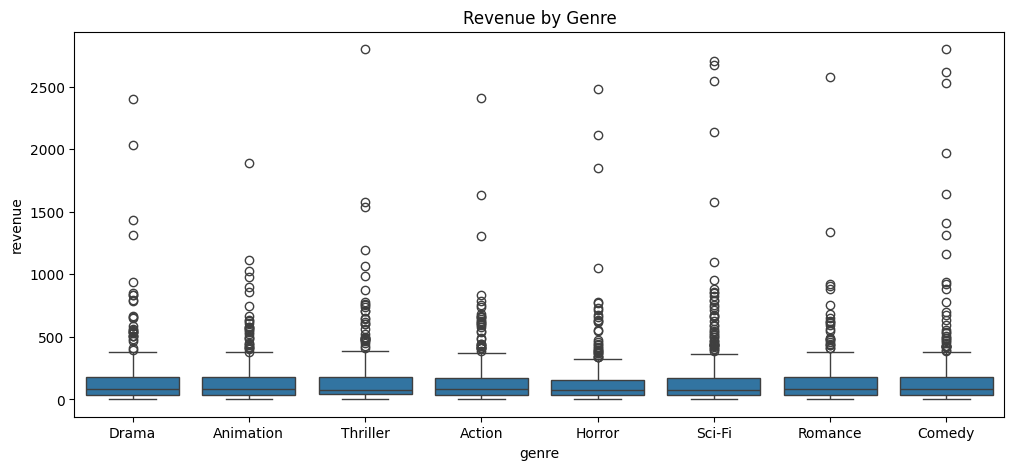

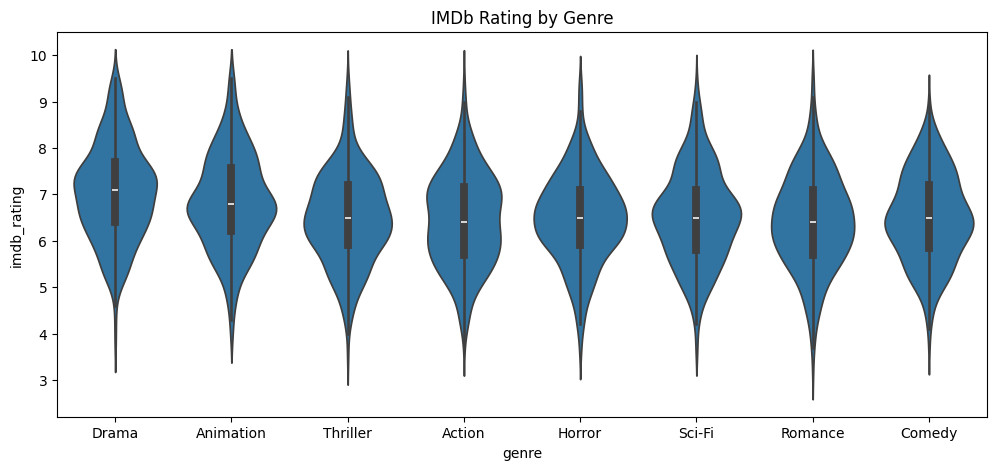


Average profit margin by genre:
 genre
Action       3.403968
Thriller     3.392471
Comedy       3.236549
Romance      3.230574
Animation    3.169065
Sci-Fi       3.048293
Horror       2.989371
Drama        2.942004
Name: profit_margin, dtype: float64

Total Oscar wins by genre:
 genre
Drama        262
Comedy       228
Animation    226
Horror       211
Sci-Fi       198
Action       196
Thriller     190
Romance      177
Name: oscar_wins, dtype: int64
genre
Action       0.997104
Animation    1.019193
Comedy       0.944941
Drama        1.020762
Horror       0.950426
Romance      1.008162
Sci-Fi       0.998235
Thriller     0.967677
Name: imdb_rating, dtype: float64


In [15]:
# 5.1 Genre comparison
plt.figure(figsize=(12,5))
sns.boxplot(x='genre', y='budget', data=df)
plt.title('Budget by Genre')
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='genre', y='revenue', data=df)
plt.title('Revenue by Genre')
plt.show()

plt.figure(figsize=(12,5))
sns.violinplot(x='genre', y='imdb_rating', data=df)
plt.title('IMDb Rating by Genre')
plt.show()

profit_by_genre = df.groupby('genre')['profit_margin'].mean().sort_values(ascending=False)
print("\nAverage profit margin by genre:\n", profit_by_genre)

oscar_by_genre = df.groupby('genre')['oscar_wins'].sum().sort_values(ascending=False)
print("\nTotal Oscar wins by genre:\n", oscar_by_genre)
#Question
rating_sd_by_genre = df.groupby('genre')['imdb_rating'].std()
print(rating_sd_by_genre)

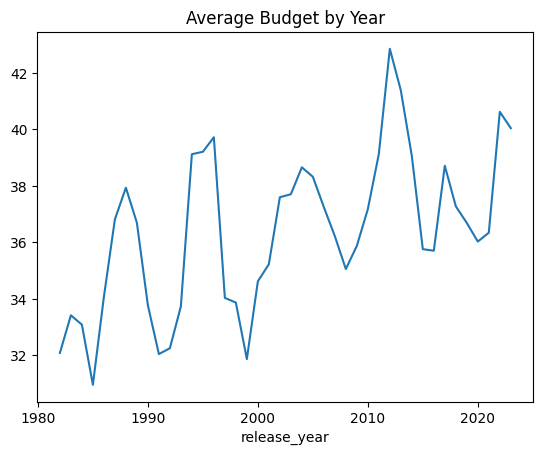

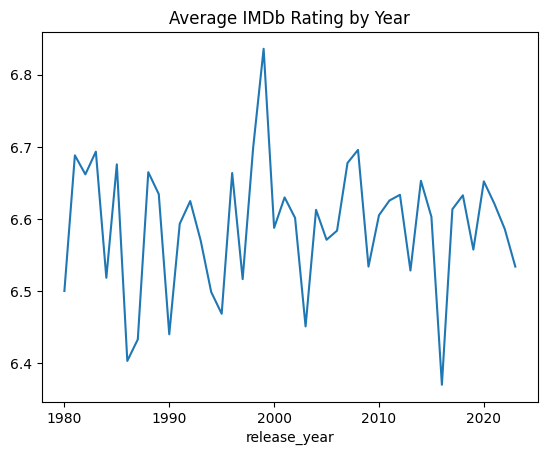

              release_year  imdb_rating
release_year      1.000000     0.004741
imdb_rating       0.004741     1.000000


In [16]:
# 5.2 
df['release_year'] = df['release_year'].astype(int)
budget_avg = df.groupby('release_year')['budget'].mean().rolling(3).mean()
budget_avg.plot(title='Average Budget by Year')
plt.show()

rating_avg = df.groupby('release_year')['imdb_rating'].mean()
rating_avg.plot(title='Average IMDb Rating by Year')
plt.show()
correlation = df[['release_year','imdb_rating']].corr()
print(correlation)

In [17]:
#5.3
top_directors = df['director'].value_counts().head(10).index
top_df = df[df['director'].isin(top_directors)]
director_stats = top_df.groupby('director').agg({
    'imdb_rating':'mean',
    'profit_margin':'mean',
    'oscar_nominations':'mean'
}).sort_values('imdb_rating', ascending=False)
print("\nTop 10 directors stats:\n", director_stats)


Top 10 directors stats:
                    imdb_rating  profit_margin  oscar_nominations
director                                                        
Greta Gerwig          6.673288       3.023387           1.616438
Christopher Nolan     6.645763       3.091015           1.705085
Steven Spielberg      6.629221       3.306000           1.678571
Ridley Scott          6.622603       2.996799           1.660959
Alfonso Cuarón        6.608803       3.243392           1.728873
Quentin Tarantino     6.599670       3.306999           1.600660
James Cameron         6.565320       3.323416           1.390572
Patty Jenkins         6.556563       3.307614           1.559375
Denis Villeneuve      6.512092       3.072892           1.516340
Martin Scorsese       6.505281       3.066144           1.600660
